# 2.2 Analisis Exploratorio de Datos

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

## Carga de datos

In [2]:
df = pd.read_csv('./data/titanic_clean.csv')
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Muestra aleatoria

In [3]:
df.sample(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
562,0,2,male,28.0,0,0,13.5000,S
676,0,3,male,24.5,0,0,8.0500,S
341,1,1,female,24.0,3,2,263.0000,S
689,1,1,female,15.0,0,1,211.3375,S


## Ejercicio 1. Distribucion de edades

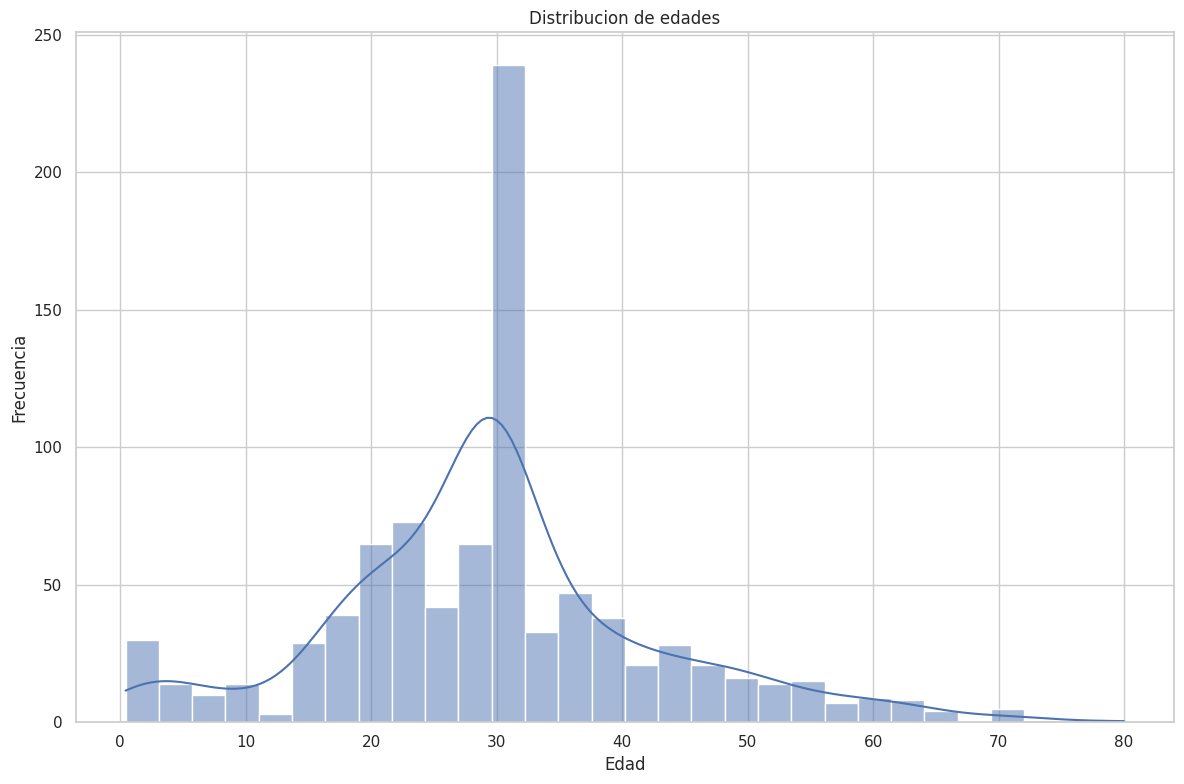

In [4]:
plt.figure(figsize=(12, 8))
sns.histplot(df, x='Age', kde=True, color='#4C72B0')
plt.title('Distribucion de edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

## Ejercicio 2. Sobrevivientes por clase

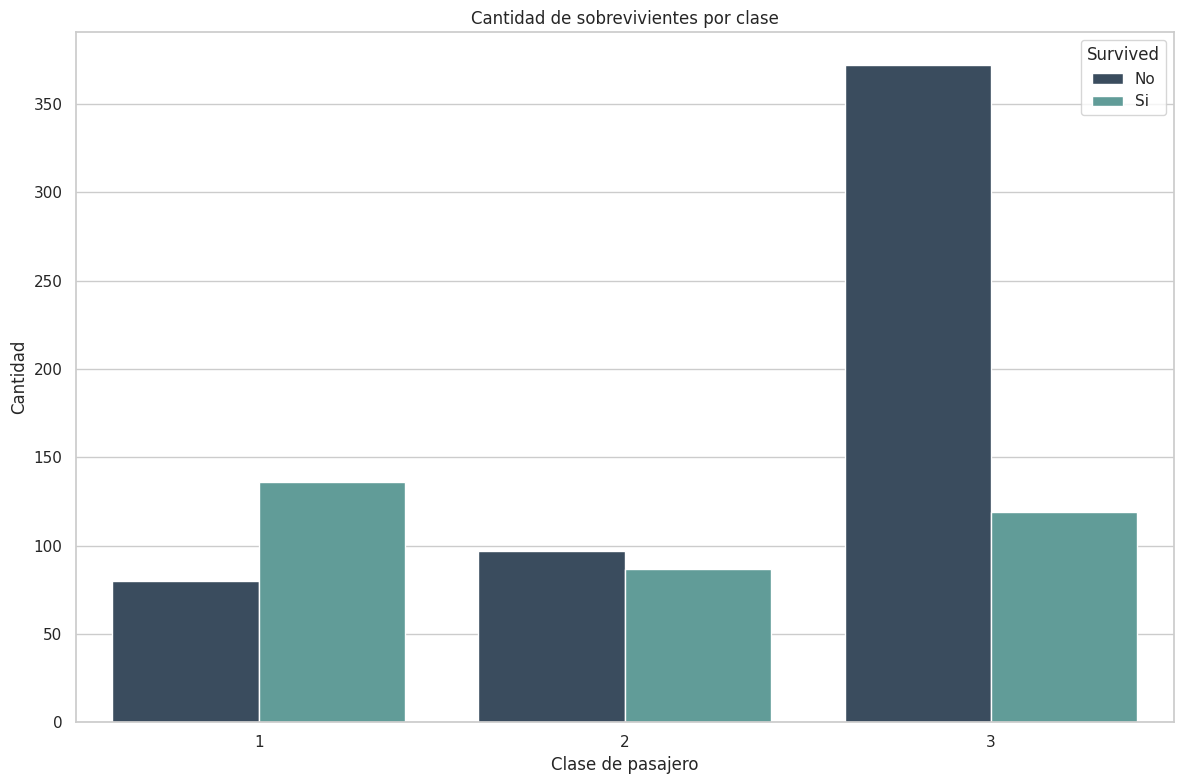

In [5]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='Pclass', hue='Survived', palette=['#344C64', '#57A6A1'])
plt.title('Cantidad de sobrevivientes por clase')
plt.xlabel('Clase de pasajero')
plt.ylabel('Cantidad')
plt.legend(title='Survived', labels=['No', 'Si'])
plt.tight_layout()
plt.show()

## Ejercicio 3. Sobrevivientes por genero

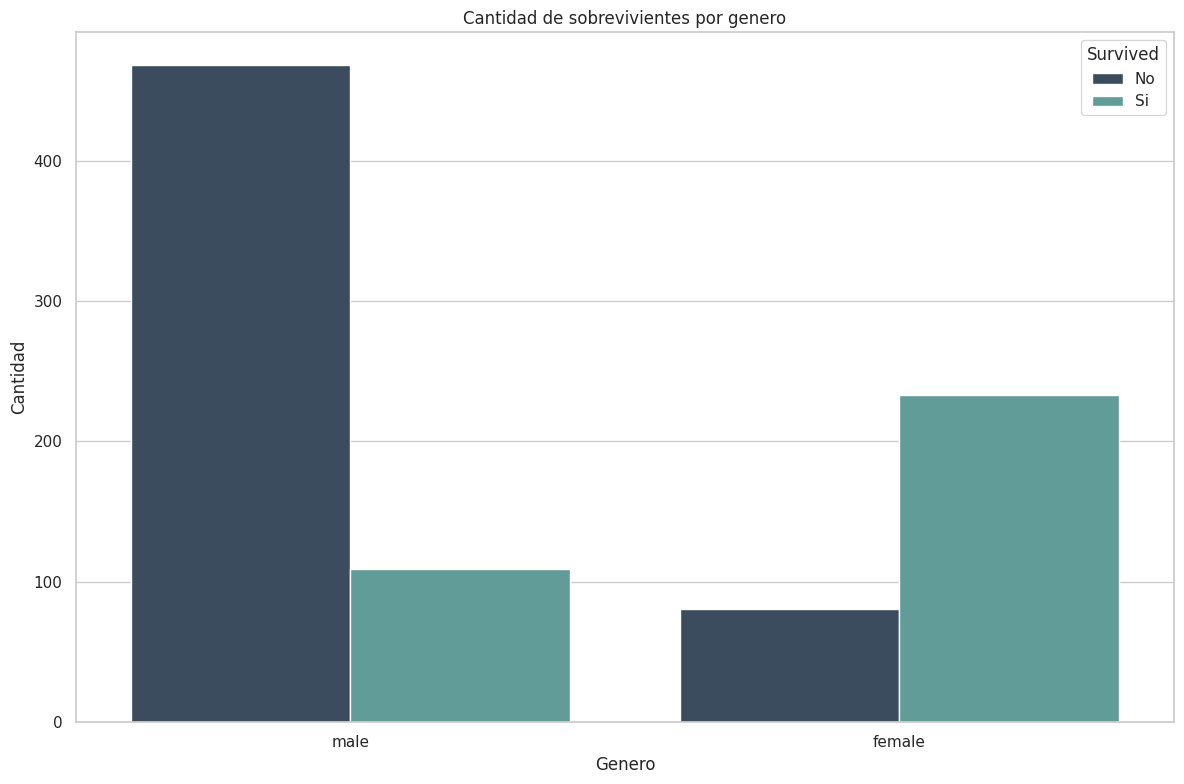

In [6]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='Sex', hue='Survived', palette=['#344C64', '#57A6A1'])
plt.title('Cantidad de sobrevivientes por genero')
plt.xlabel('Genero')
plt.ylabel('Cantidad')
plt.legend(title='Survived', labels=['No', 'Si'])
plt.tight_layout()
plt.show()

## Ejercicio 4. Sobrevivientes por puerto de embarque

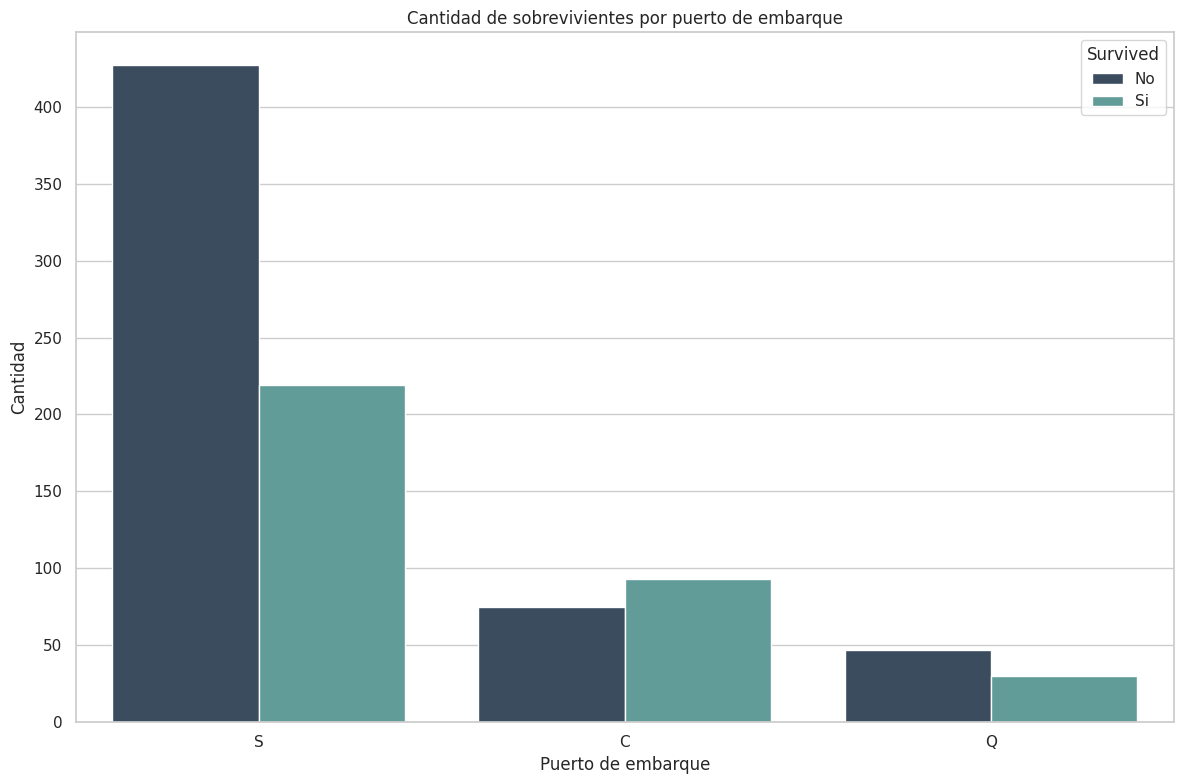

In [7]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='Embarked', hue='Survived', palette=['#344C64', '#57A6A1'])
plt.title('Cantidad de sobrevivientes por puerto de embarque')
plt.xlabel('Puerto de embarque')
plt.ylabel('Cantidad')
plt.legend(title='Survived', labels=['No', 'Si'])
plt.tight_layout()
plt.show()

## Ejercicio 5. Supervivencia por grupo de edad

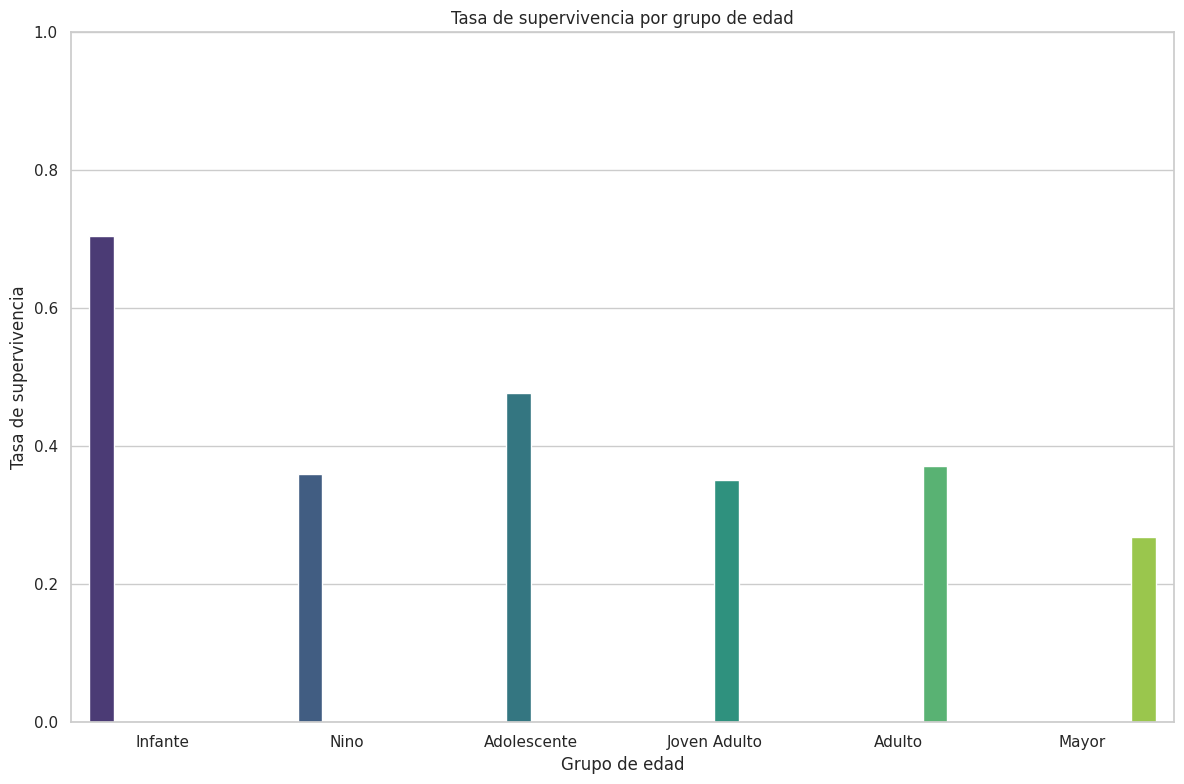

In [8]:
age_bins = [0, 5, 12, 17, 29, 59, float('inf')]
age_labels = ['Infante', 'Nino', 'Adolescente', 'Joven Adulto', 'Adulto', 'Mayor']
df_age_groups = df.copy()
df_age_groups['AgeGroup'] = pd.cut(df_age_groups['Age'], bins=age_bins, labels=age_labels, include_lowest=True)
survival_by_age_group = df_age_groups.groupby('AgeGroup', observed=False)['Survived'].mean().reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=survival_by_age_group, x='AgeGroup', y='Survived', hue='AgeGroup', palette='viridis', legend=False)
plt.title('Tasa de supervivencia por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Tasa de supervivencia')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Ejercicio 6. Conteo de pasajeros por clase

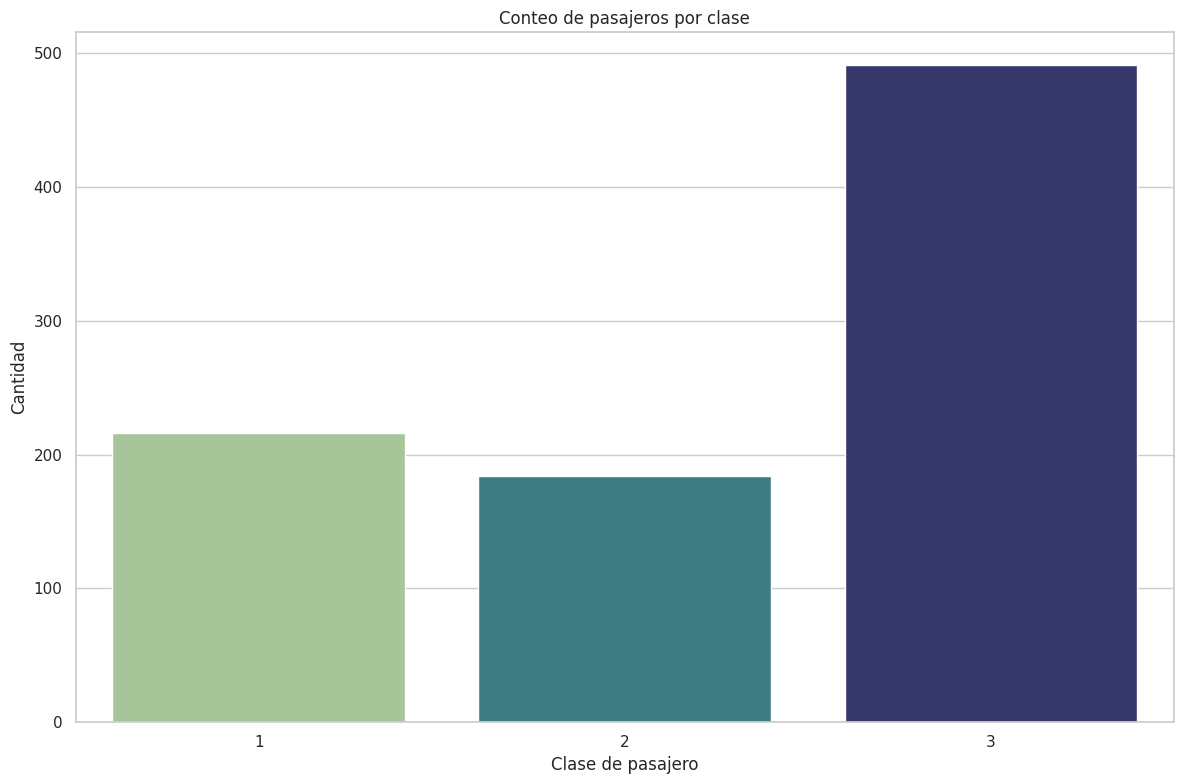

In [9]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='Pclass', hue='Pclass', palette='crest', legend=False)
plt.title('Conteo de pasajeros por clase')
plt.xlabel('Clase de pasajero')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

## Ejercicio 7. Genero dentro de cada clase

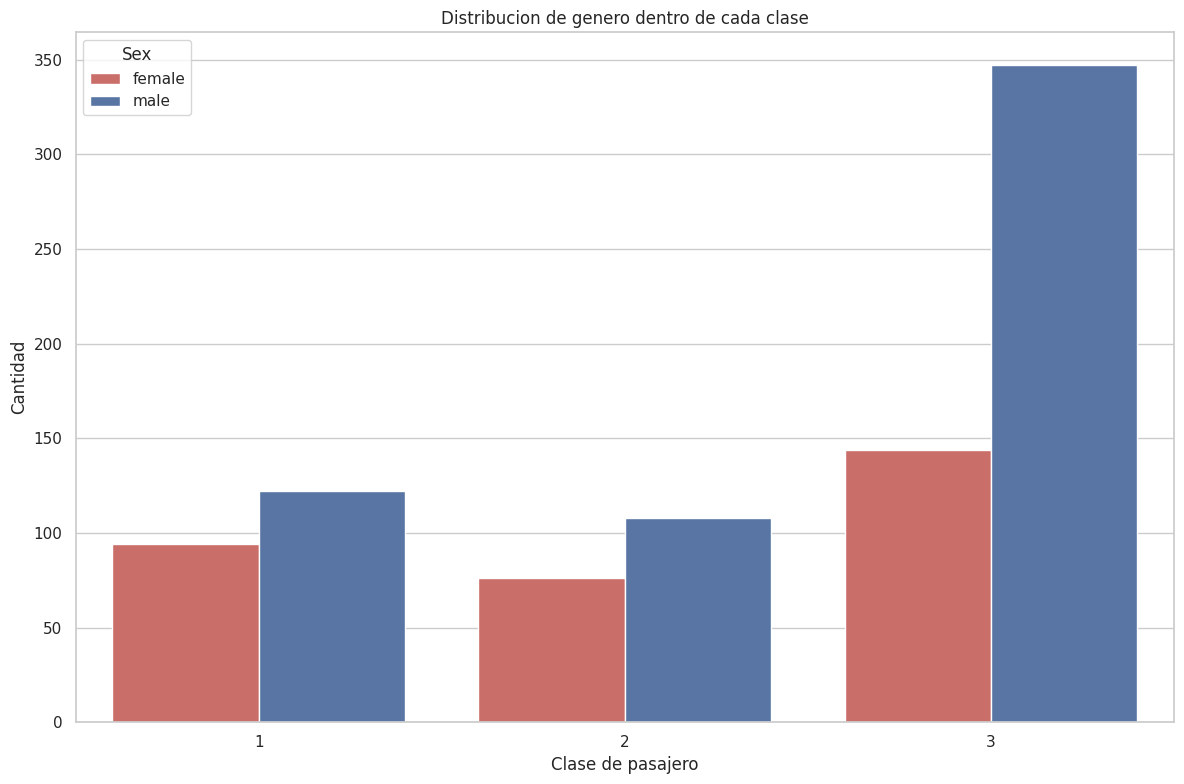

In [10]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='Pclass', hue='Sex', palette=['#D95F59', '#4C72B0'])
plt.title('Distribucion de genero dentro de cada clase')
plt.xlabel('Clase de pasajero')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

## Ejercicio 8. Clase por puerto de embarque

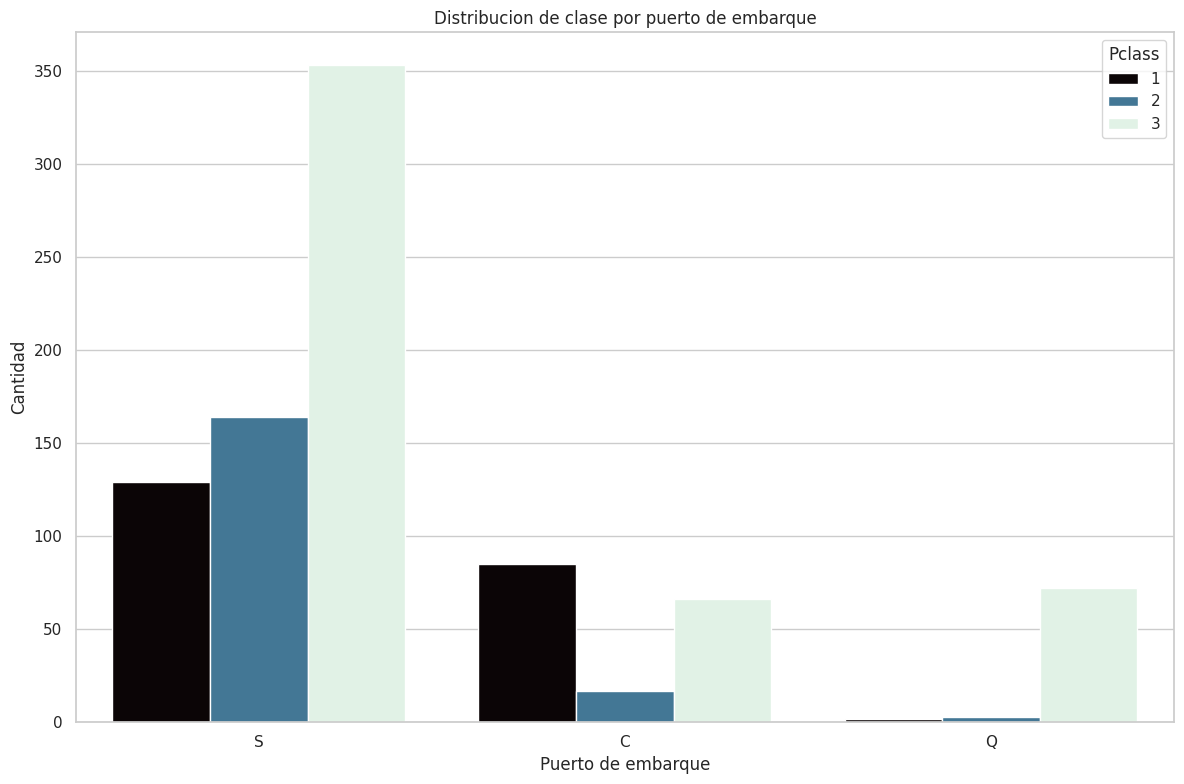

In [11]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='Embarked', hue='Pclass', palette='mako')
plt.title('Distribucion de clase por puerto de embarque')
plt.xlabel('Puerto de embarque')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

## Ejercicio 9. Conteo de pasajeros por genero

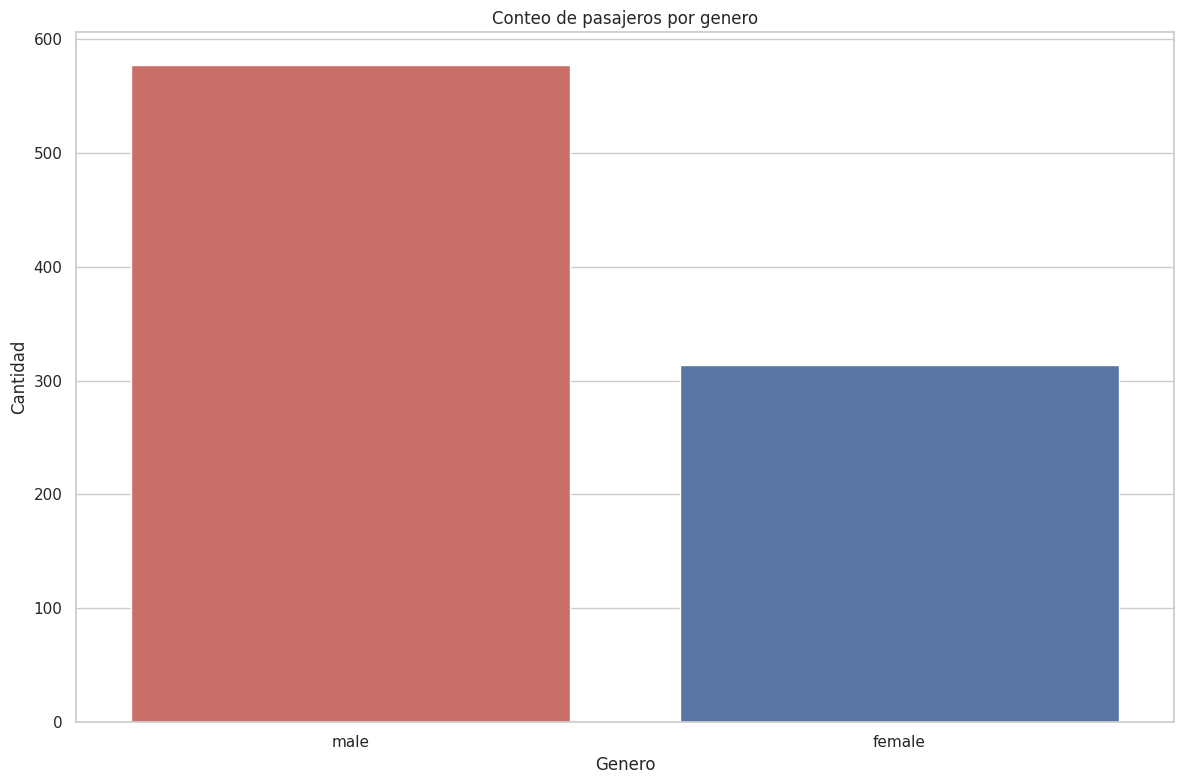

In [12]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='Sex', hue='Sex', palette=['#D95F59', '#4C72B0'], legend=False)
plt.title('Conteo de pasajeros por genero')
plt.xlabel('Genero')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

## Ejercicio 10. Edad maxima y minima

In [13]:
print(f"Edad minima: {df['Age'].min()}")
print(f"Edad maxima: {df['Age'].max()}")

Edad minima: 0.42
Edad maxima: 80.0


## Ejercicio 11. Distribucion de edades con media, mediana y moda

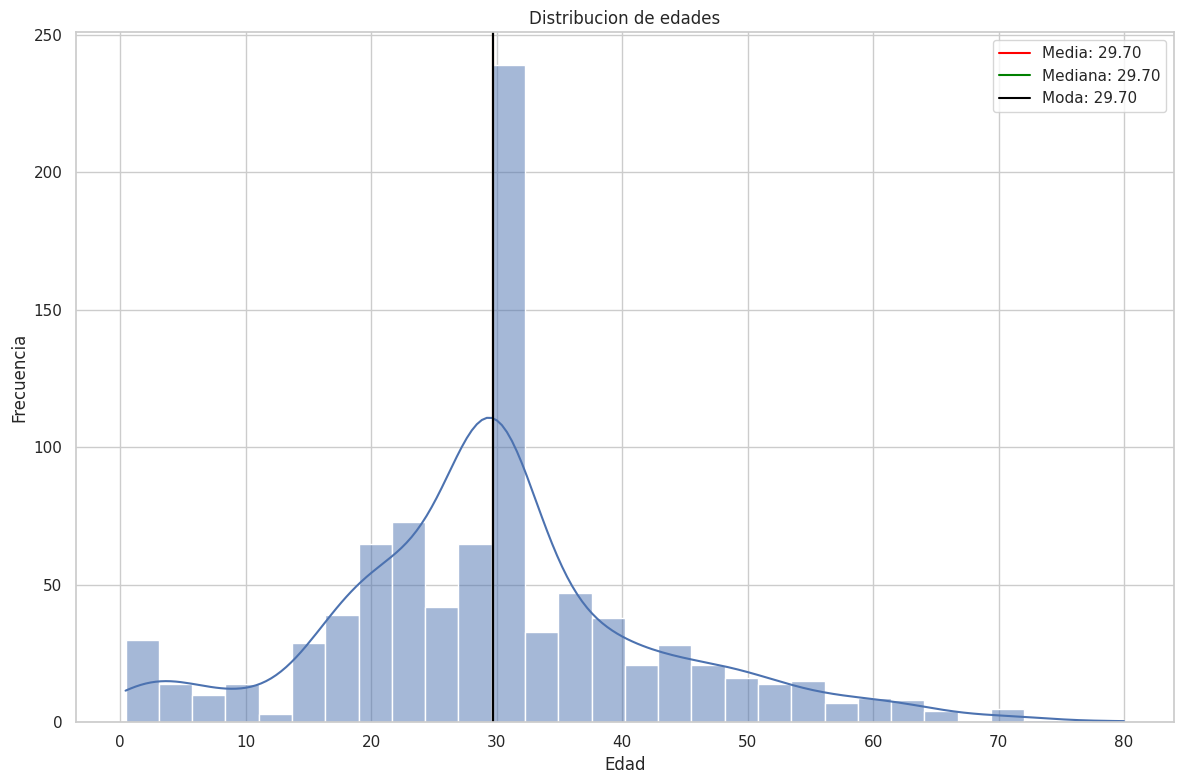

Media: 29.70
Mediana: 29.70
Moda: 29.70


In [14]:
age_mean = df['Age'].mean()
age_median = df['Age'].median()
age_mode = df['Age'].mode()[0]

plt.figure(figsize=(12, 8))
sns.histplot(df, x='Age', kde=True, color='#4C72B0')
plt.axvline(age_mean, color='red', label=f'Media: {age_mean:.2f}')
plt.axvline(age_median, color='green', label=f'Mediana: {age_median:.2f}')
plt.axvline(age_mode, color='black', label=f'Moda: {age_mode:.2f}')
plt.title('Distribucion de edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Media: {age_mean:.2f}')
print(f'Mediana: {age_median:.2f}')
print(f'Moda: {age_mode:.2f}')

## Ejercicio 12. Boxplot de edad

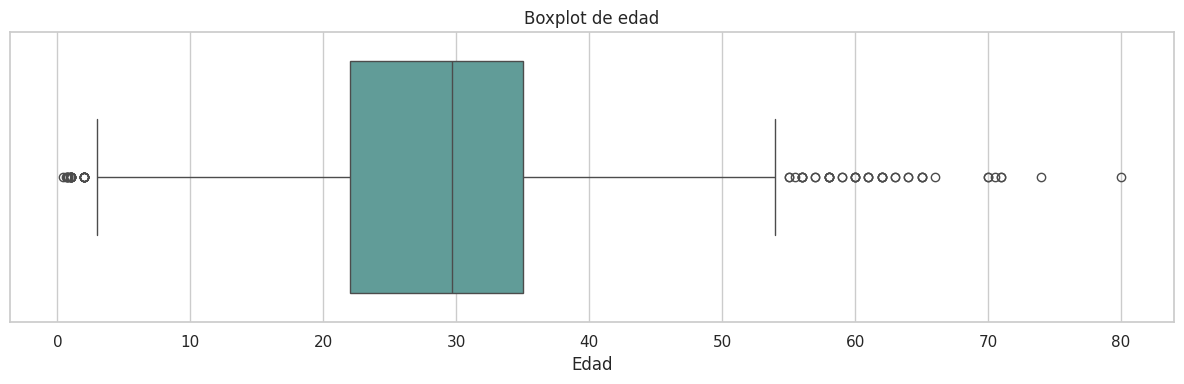

In [15]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=df, x='Age', color='#57A6A1')
plt.title('Boxplot de edad')
plt.xlabel('Edad')
plt.tight_layout()
plt.show()

## Ejercicio 13. Tarifa maxima y minima

In [16]:
print(f"Tarifa minima: {df['Fare'].min()}")
print(f"Tarifa maxima: {df['Fare'].max()}")

Tarifa minima: 0.0
Tarifa maxima: 512.3292


## Ejercicio 14. Distribucion de tarifas con media, mediana y moda

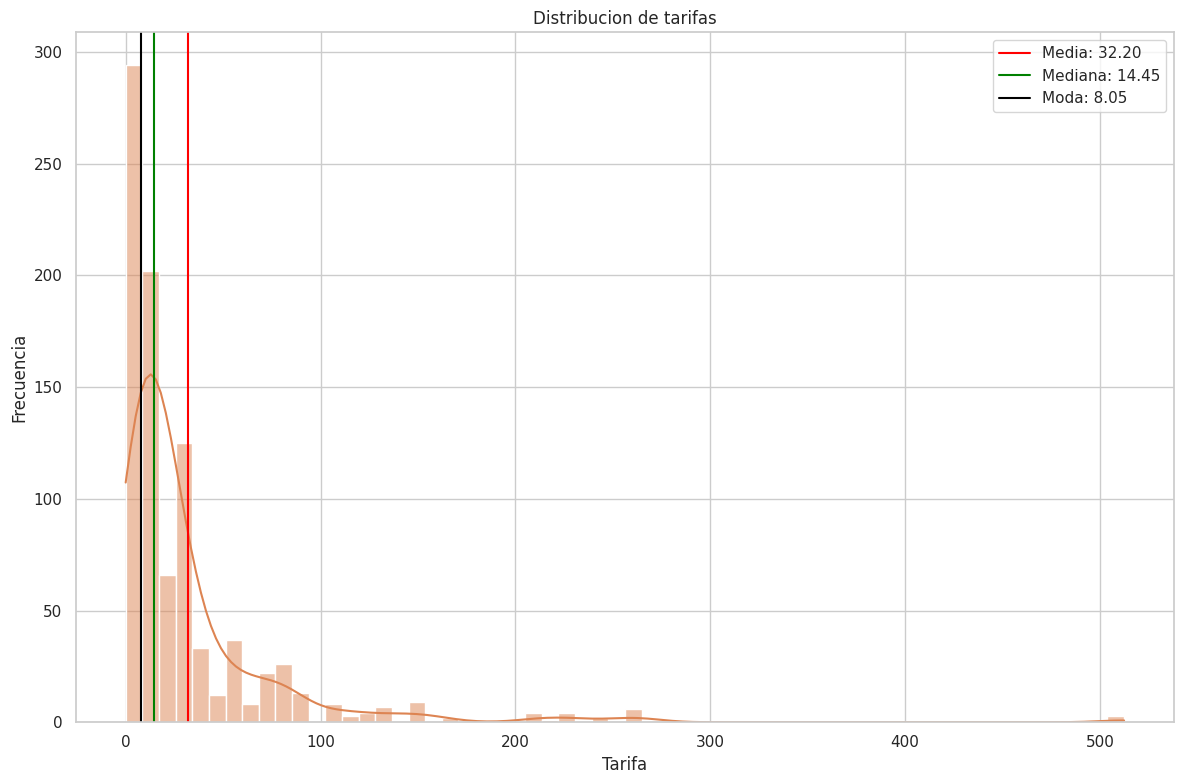

Media: 32.20
Mediana: 14.45
Moda: 8.05


In [17]:
fare_mean = df['Fare'].mean()
fare_median = df['Fare'].median()
fare_mode = df['Fare'].mode()[0]

plt.figure(figsize=(12, 8))
sns.histplot(df, x='Fare', kde=True, color='#DD8452')
plt.axvline(fare_mean, color='red', label=f'Media: {fare_mean:.2f}')
plt.axvline(fare_median, color='green', label=f'Mediana: {fare_median:.2f}')
plt.axvline(fare_mode, color='black', label=f'Moda: {fare_mode:.2f}')
plt.title('Distribucion de tarifas')
plt.xlabel('Tarifa')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Media: {fare_mean:.2f}')
print(f'Mediana: {fare_median:.2f}')
print(f'Moda: {fare_mode:.2f}')

## Ejercicio 15. Boxplot de tarifa

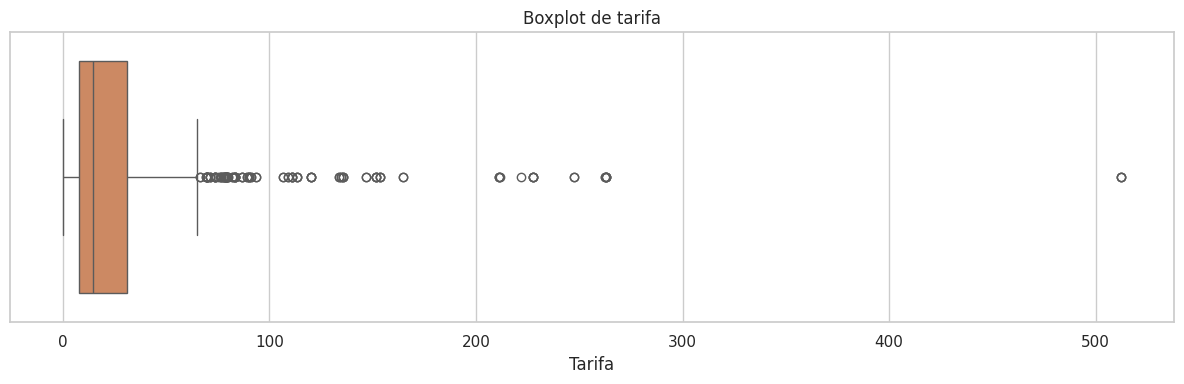

In [18]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=df, x='Fare', color='#DD8452')
plt.title('Boxplot de tarifa')
plt.xlabel('Tarifa')
plt.tight_layout()
plt.show()

## Ejercicio 16. Pasajeros con tarifa 0

In [19]:
df[df['Fare'] == 0].sort_values(by='Pclass')

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
263,0,1,male,40.000000,0,0,0.0,S
815,0,1,male,29.699118,0,0,0.0,S
822,0,1,male,38.000000,0,0,0.0,S
633,0,1,male,29.699118,0,0,0.0,S
806,0,1,male,39.000000,0,0,0.0,S
277,0,2,male,29.699118,0,0,0.0,S
466,0,2,male,29.699118,0,0,0.0,S
413,0,2,male,29.699118,0,0,0.0,S
674,0,2,male,29.699118,0,0,0.0,S
732,0,2,male,29.699118,0,0,0.0,S


## Ejercicio 17. Conteo de pasajeros por SibSp

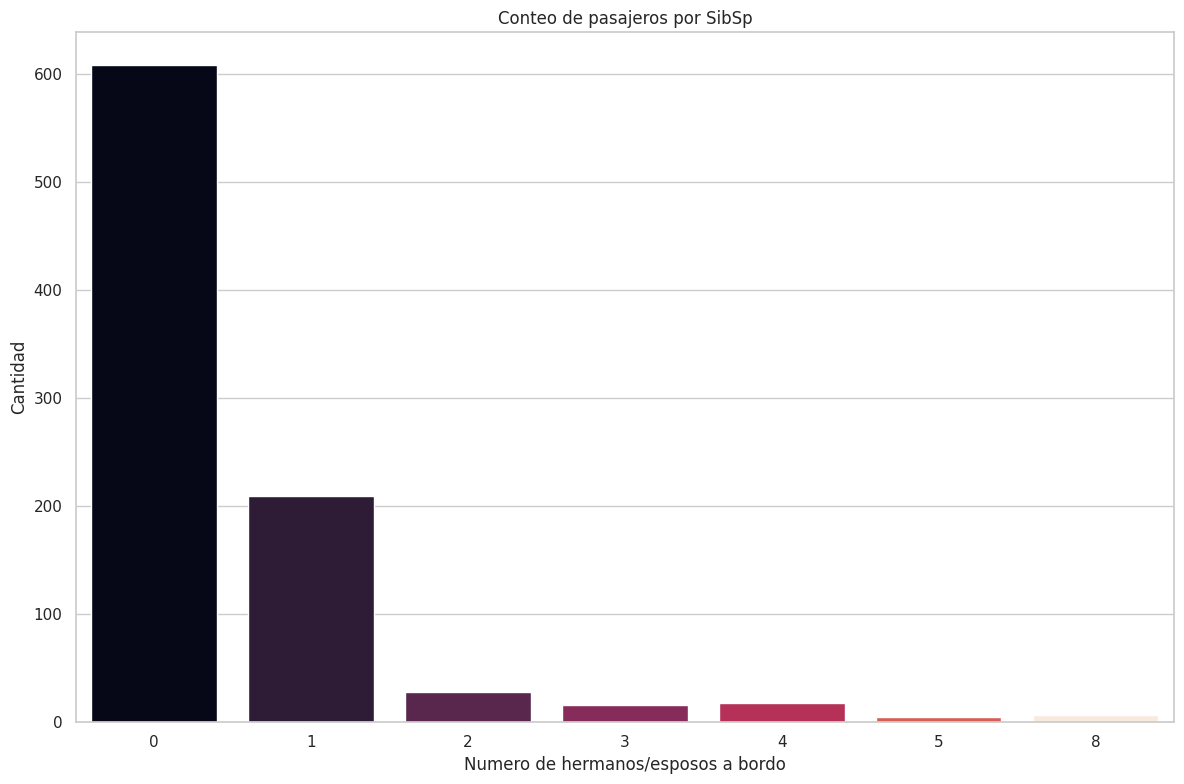

In [20]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='SibSp', hue='SibSp', palette='rocket', legend=False)
plt.title('Conteo de pasajeros por SibSp')
plt.xlabel('Numero de hermanos/esposos a bordo')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

## Ejercicio 18. Tasa de supervivencia por SibSp

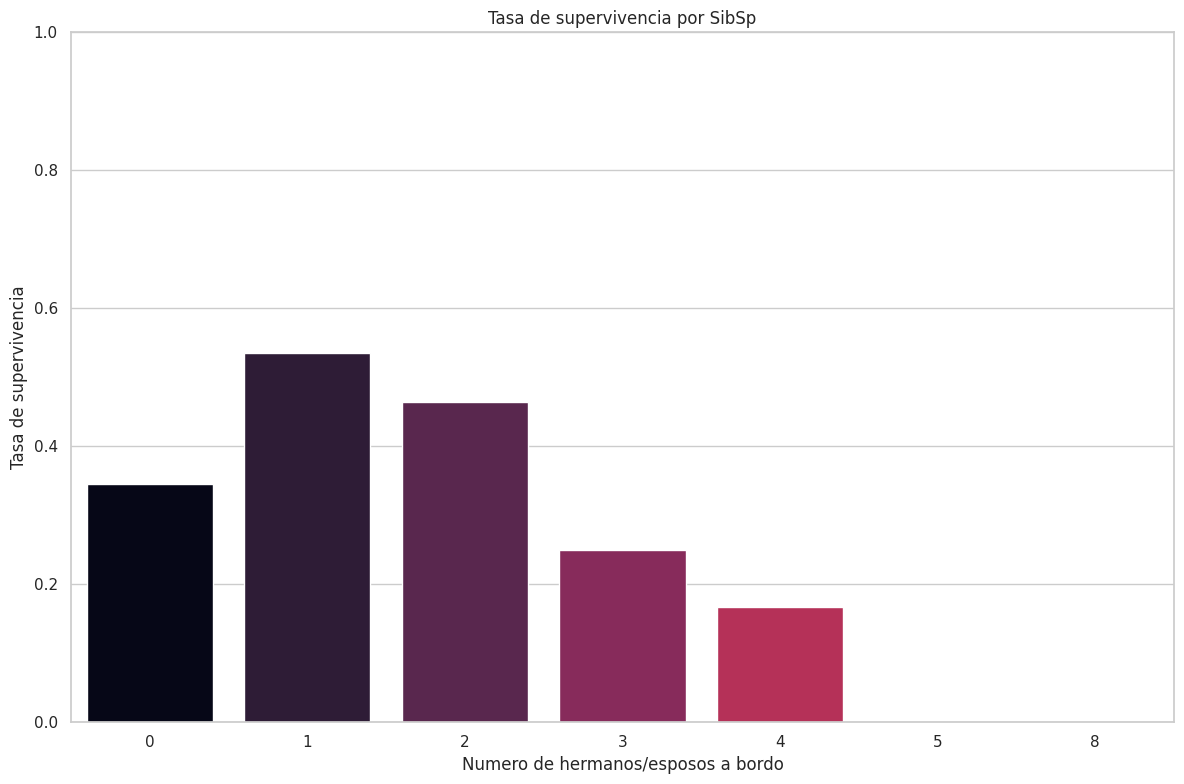

In [21]:
survival_by_sibsp = df.groupby('SibSp', as_index=False)['Survived'].mean()

plt.figure(figsize=(12, 8))
sns.barplot(data=survival_by_sibsp, x='SibSp', y='Survived', hue='SibSp', palette='rocket', legend=False)
plt.title('Tasa de supervivencia por SibSp')
plt.xlabel('Numero de hermanos/esposos a bordo')
plt.ylabel('Tasa de supervivencia')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Ejercicio 19. Porcentaje de supervivencia por SibSp

In [22]:
survival_percentage_by_sibsp = (df.groupby('SibSp')['Survived'].mean() * 100).round(2).reset_index(name='SurvivalPercentage')
survival_percentage_by_sibsp

,SibSp,SurvivalPercentage
0,0,34.54
1,1,53.59
2,2,46.43
3,3,25.00
4,4,16.67
5,5,0.00
6,8,0.00


## Ejercicio 20. Matriz de correlacion

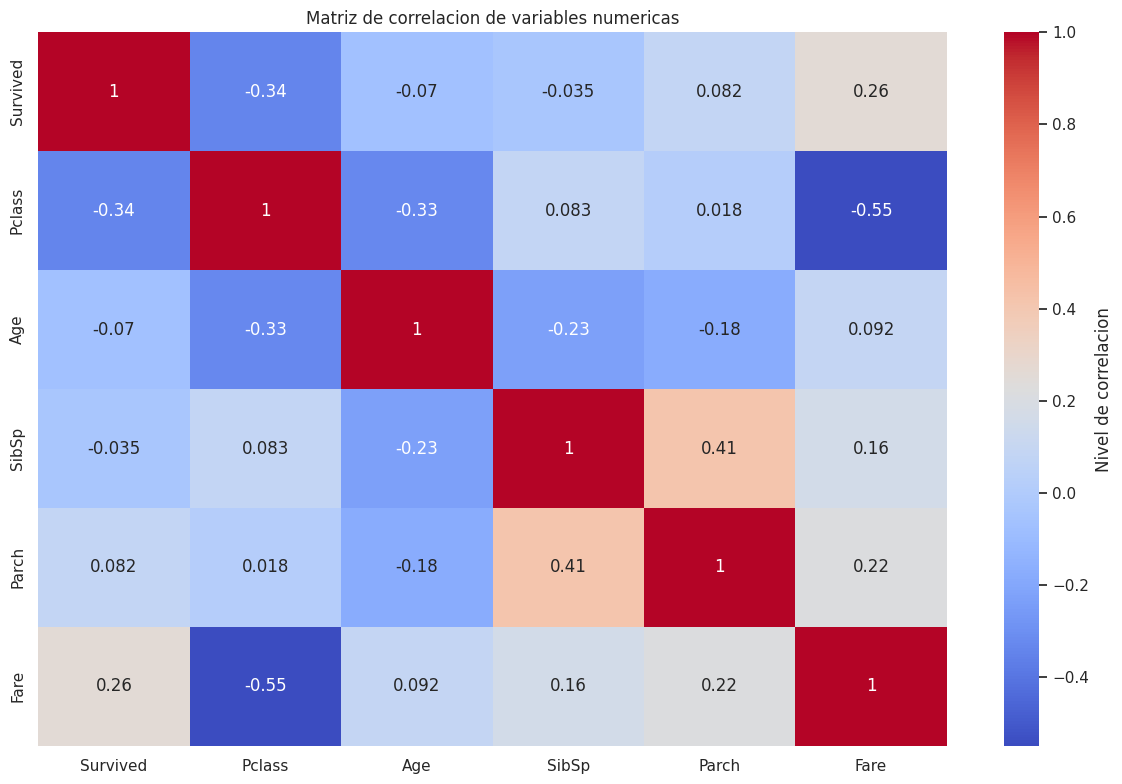

In [23]:
plt.figure(figsize=(12, 8))
correlation_matrix = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', cbar_kws={'label': 'Nivel de correlacion'})
plt.title('Matriz de correlacion de variables numericas')
plt.tight_layout()
plt.show()